In [1]:
%cd ..
!git clone https://github.com/dodo47/GCDetection

/home/ludi/Documents/Uni/magistrale/AII/AII-Assignment
fatal: destination path 'GCDetection' already exists and is not an empty directory.


Load the datasets using utils.data.prepare_data()

In [2]:
from torch.utils.data import Dataset, DataLoader

class FrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.frames = np.stack(df.frame.values)
        self.labels = np.array(df.y)
        self.transform =  transform

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        if self.transform:
            ch1 = self.transform(self.frames[idx][0])
            ch2 = self.transform(self.frames[idx][1])
            img = np.stack(ch1, ch2)
        else:
            img = self.frames[idx]
            
        return torch.tensor(img).float(), torch.tensor(self.labels[idx])


In [3]:
from utils import data
import pandas as pd
import numpy as np
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

FCC, VCC = data.prepare_data()
all_frames = pd.concat((FCC, VCC))
all_frames = all_frames[~all_frames.frame.apply(lambda x: np.isnan(x).any())]

train_df = all_frames.sample(frac=0.7, random_state=42)
rest = all_frames.drop(train_df.index)
val_df = rest.sample(frac=1/3, random_state=42)
test_df = rest.drop(val_df.index)



train_ds = DataLoader(
    FrameDataset(train_df), 
    batch_size=64, # Molto più efficiente per la GPU
    shuffle=True,
    num_workers=4, # Carica i dati in parallelo su altri core CPU
    pin_memory=True # Velocizza il passaggio RAM -> GPU
)
val_ds = DataLoader(FrameDataset(val_df), batch_size=64, shuffle=False)
test_ds = DataLoader(FrameDataset(test_df), batch_size=64, shuffle=False)

Data Exploration

<Axes: xlabel='pGC', ylabel='Count'>

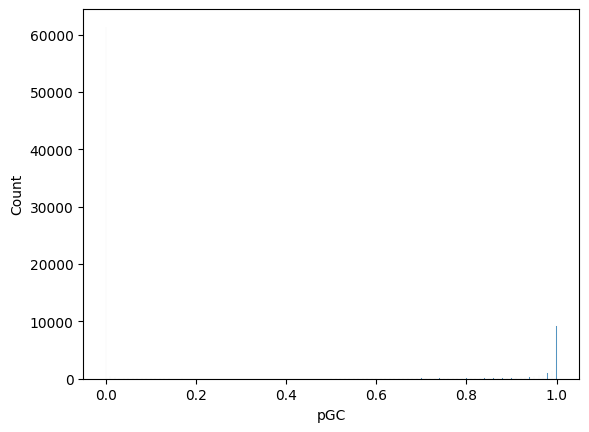

In [4]:
import seaborn as sns

sns.histplot(all_frames["pGC"])

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np



class ConvGp(nn.Module):
    def __init__(self, device, in_channels, out_channels, kernel_size, M, padding=0, stride=1, log_s=1.0, log_ls=1.0, name=None):
        super().__init__()
        self.k = kernel_size
        self.out_channels = out_channels
        self.P = in_channels * kernel_size * kernel_size 
        self.M = M 
        self.padding = padding
        self.stride = stride
        self.Z = nn.Parameter(torch.randn(M, self.P) * 0.1)
        self.log_s = nn.Parameter(torch.log(torch.tensor(log_s)))
        self.log_ls = nn.Parameter(torch.log(torch.tensor(log_ls)))
        self.name = name
        self.device = device
    
    @property
    def sigma(self): 
        # Softplus is more stable than exp for scales
        return F.softplus(self.log_s)

    @property
    def lengthscale(self): 
        return F.softplus(self.log_ls) 

    def _rbf(self, x1, x2, s, ls):
        """Kernel RBF modulare con gestione automatica del broadcasting."""
        # Se x1 è (N, L, P) e x2 è (M, P), cdist richiede x2 (1, M, P)
        if x1.dim() == 3 and x2.dim() == 2:
            x2 = x2.unsqueeze(0)
            
        dist_sq = torch.cdist(x1, x2, p=2)**2
        return (s**2) * torch.exp(-dist_sq / (2 * (ls**2)))

class ExtractorConvGP(ConvGp):
    def __init__(self, device, in_channels, out_channels, kernel_size, M, padding=0, stride=1, log_s=0.54, log_ls=0.54, name=None):
        super().__init__(device, in_channels, out_channels, kernel_size, M, padding, stride, log_s, log_ls, name)
        self.m = nn.Parameter(torch.randn(M, out_channels)) # Inducing responses
        self.L_S_raw = nn.Parameter(torch.eye(M)) # Posterior learned covariance.

    def forward(self, x):

        N, C, H, W = x.shape
        s = self.sigma
        ls = self.lengthscale

        # Input unfolding (patch extraction, L=num patches): 
        # (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, stride=self.stride).transpose(1, 2)
        L = patches.shape[1]

        # Similarity matrixes.
        # K_zz: add jitter for numerical stability and invertibility.
        K_zz = self._rbf(self.Z, self.Z, s, ls) + 1e-5 * torch.eye(self.M, device=self.device)
        K_xz = self._rbf(patches, self.Z.unsqueeze(0), s, ls) # (N, L, M)

        # Cholesky decomposition to avoid direct matrix inversion.
        L_z = torch.linalg.cholesky(K_zz)
        # A = K_xz @ K_zz^-1
        A = torch.cholesky_solve(K_xz.transpose(1, 2), L_z).transpose(1, 2) # (N, L, M)

        # Predictive mean: (N, L, M) @ (M, out) -> (N, L, out)
        mean = torch.matmul(A, self.m)

        # Predictive variance: 
        # Extract S from L_S_raw.
        L_S = torch.tril(self.L_S_raw)
        S = L_S @ L_S.T 

        # The followinf is an efficient formula to compute the posterior variance 
        # (diag(covariance)) of the query variables.

        # Difference between prior covariance and posterior covariance (learned).
        # This represents "uncertainty reduction". 
        K_diff = K_zz - S
        
        # - torch.matmul(A, K_diff) Transports uncertainty over query vars.A
        # - torch.sum() and * A are an efficient way of computing the variance (diagonal).
        # - term2 can be defined as the "information gain". The closer the query variables are to
        # inducing points the more "certainty" is obtained and the bigger term2 gets.
        term2 = torch.sum(torch.matmul(A, K_diff) * A, dim=-1, keepdim=True) # (N, L, 1)
        
        # (s**2) - term2 computes the predictive variance. prior variance - what was learnt.
        var = (s**2) - term2 
        var = var.clamp(min=1e-6) # Avoid negative values.

        # Sampling.
        # - sample a 0 mean, 1 variance normal with matching shape to f_mean.
        eps = torch.randn_like(mean)
        sample = mean + eps * torch.sqrt(var) # Adjust with learnt params.

        # Reshape
        h_out = int(L**0.5)
        return sample.transpose(1, 2).view(N, self.out_channels, h_out, h_out)

class ClassifierConvGP(ConvGp):
    def __init__(self, device, in_channels, in_shape, out_channels, kernel_size, M, padding=0, stride=1, log_s=0.54, log_ls=0.54, name=None):
        super().__init__(device, in_channels, out_channels, kernel_size, M, padding, stride, log_s, log_ls, name)  
        h_in, w_in = in_shape
        h_out = (h_in + 2 * padding - kernel_size) // stride + 1
        w_out = (w_in + 2 * padding - kernel_size) // stride + 1
        L = h_out * w_out
        self.m = nn.Parameter(torch.zeros(out_channels, M, 1))
        self.L_S_raw = nn.Parameter(torch.eye(M).unsqueeze(0).repeat(out_channels, 1, 1))
        self.w_logits = nn.Parameter(torch.zeros(L))


    def forward(self, x):
        N, C, H, W = x.shape
        s, ls = self.sigma, self.lengthscale
        
        # Input unfolding (patch extraction, L=num patches): 
        # (N, C, H, W) -> (N, L, P)
        patches = F.unfold(x, kernel_size=self.k, padding=self.padding, stride=self.stride).transpose(1, 2)

        # Similarity matrixes.
        # K_zz: add jitter for numerical stability and invertibility.
        K_zz = self._rbf(self.Z, self.Z, s, ls)  + 1e-5 * torch.eye(self.M, device=self.device)
        K_xz = self._rbf(patches, self.Z, s, ls)
        # Convert logits to sum 1 weights.
        w = F.softmax(self.w_logits, dim=0) # (L)
        # Weight K_xz with w. Each entry collects and condenses all patch similarities 
        # of a batch image against Z inducing patches.
        kw_xz = torch.einsum('l,nlm->nm', w, K_xz) # (N, M)
        
        # Cholesky decomposition to avoid direct matrix inversion.
        L_z = torch.linalg.cholesky(K_zz)     

        # v = inv(L_z) @ Kw_zx
        # L_z @ v = kw_xz.T  => v 
        v = torch.linalg.solve_triangular(L_z, kw_xz.T, upper=False) # (M, N)

        # Predictive mean:
        # Given mu = kw_xz @ inv(K_zz) @ m and inv(K_zz) = inv(K_zz).T and kw_xz.T = kw_zx
        # mean = m^T @ inv(K_zz) @ kw_zx
        # mean = (inv(L_z) @ m).T @ v
        v_m = torch.linalg.solve_triangular(L_z.unsqueeze(0), self.m, upper=False) # (C, M, 1)
        mean = torch.matmul(v_m.transpose(1, 2), v).squeeze(-2).T # (N, C)

        # Predictive variance (whitening included):
        # sum(v^2) = diag(Kw_xz @ inv(K_zz) @ Kw_zx)
        # "Explained" variance thanks to inducing points. 
        term_std = torch.sum(v**2, dim=0, keepdim=True).T # (N, 1)
        
        # Build Cholesky factor of the learned variational covariance S.
        L_S = torch.tril(self.L_S_raw)
        
        # Compute the projection of the inducing uncertainty onto the data space.
        # This uses the "Whitened" representation: S is learned in a space 
        # where K_zz correlation is already factored out.
        # v_S = L_S.T @ (inv(L_z) @ Kw_zx) = L_S.T @ v
        v_S = torch.matmul(L_S.transpose(-1, -2), v.unsqueeze(0)) # (C, M, N)
        
        # term_S = diag(A @ S @ A^T).
        # This is the "corrective" uncertainty: we add back variance because 
        # our inducing points themselves are uncertain (learned via S).
        term_S = torch.sum(v_S**2, dim=1).T # (N, C)

        # Final variance: starts at s^2, reduces by term_std, and increases by term_S.
        # Clamp at 1e-6 to prevent negative values due to floating point errors (NaN safety).
        var = (s**2 - term_std + term_S).clamp(min=1e-6)

        return mean, var

In [6]:
class DeepCGP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def kl_divergence(self):
        total_kl = 0
        for layer in self.layers:
            # Recuperiamo i parametri
            m = layer.m  # (M, out) o (out, M, 1)
            L_S = torch.tril(layer.L_S_raw) # (M, M) o (out, M, M)
            
            # Rendiamo tutto consistente come (Batch_Dimension, M, M)
            if L_S.dim() == 2:
                L_S = L_S.unsqueeze(0)
                m = m.t().unsqueeze(-1) # (out, M, 1)

            # M = numero di inducing points
            M_dim = L_S.shape[-1]
            
            # Somma delle tracce: tr(S) = sum(L_S^2)
            trace_S = torch.sum(L_S**2, dim=(-1, -2))
            
            # Termine quadratico della media: m^T m
            mu_sq = torch.sum(m**2, dim=(-1, -2)).squeeze()
            
            # Log-determinante: 2 * sum(log(diag(L_S)))
            # Inside kl_divergence
            diagonals = torch.diagonal(L_S, dim1=-2, dim2=-1)
            # Force diagonal to be positive for the log
            log_det_S = 2.0 * torch.sum(torch.log(diagonals.abs() + 1e-8), dim=-1)
            
            # KL per ogni canale/output di questo layer
            kl_layer = 0.5 * (trace_S + mu_sq - M_dim - log_det_S)
            total_kl += kl_layer.sum()
            
        return total_kl

def elbo_loss(model, x, y, num_samples=10, beta=1.0, ):
    """
    Versione parallelizzata della ELBO senza for loop.
    """
    # 1. Ottieni media e varianza dal modello (N, C)
    mean, var = model(x)
    
    # 2. Genera rumore per tutti i campioni in un colpo solo (S, N, C)
    # S = num_samples, N = batch_size, C = num_classes
    eps = torch.randn((num_samples, *mean.shape), device=x.device)
    
    # 3. Calcola i campioni f parallelamente tramite broadcasting
    # (N, C) -> (1, N, C) + (S, N, C) * (1, N, C) = (S, N, C)
    f_samples = mean.unsqueeze(0) + eps * torch.sqrt(var.unsqueeze(0))
    
    # 4. Calcola la Log-Likelihood
    # Appiattiamo le dimensioni S e N per usare F.nll_loss in modo efficiente
    # f_samples_flat: (S*N, C)
    f_samples_flat = f_samples.reshape(-1, f_samples.shape[-1])
    log_prob = F.log_softmax(f_samples_flat, dim=-1)
    
    # Espandiamo anche i target y per matchare i campioni: (N) -> (S*N)
    y_expanded = y.repeat_interleave(num_samples).long()
    
    # Calcoliamo la NLL totale e mediamo per il numero di campioni
    total_nll = F.nll_loss(log_prob, y_expanded, reduction='sum')
    avg_log_likelihood = - (total_nll / num_samples)
    
    # 5. KL Divergence (rimane invariata, è già efficiente)
    kl_term = model.kl_divergence()
    
    return avg_log_likelihood + beta * kl_term

In [7]:
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter


def train_one_epoch(model, epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(train_ds):
        inputs, labels = data
        inputs = inputs.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        loss = elbo_loss(model, inputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_ds) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
    
    return last_loss


# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/GC_detection_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.
M = 10
model = DeepCGP([
    ExtractorConvGP(
        device=device,
        in_channels=2, 
        out_channels=8, 
        kernel_size=5, 
        M=M, 
        padding=2, 
        stride=2,
        name="extractor_1"
    ),
    ExtractorConvGP(
        device=device,
        in_channels=8,
        out_channels=16,
        kernel_size=3, 
        M=M, 
        padding=1, 
        stride=2,
        name="extractor_2"
    ),
    ClassifierConvGP(
        device=device,
        in_channels=16, 
        in_shape=(5, 5), 
        out_channels=2, 
        kernel_size=5,
        M=M, 
        padding=0, 
        stride=1,
        name="classifier"
    )
]).float().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(model, epoch_number, writer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_ds):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device, non_blocking=True).float()
            vlabels = vlabels.to(device, non_blocking=True)
            vloss = elbo_loss(model, vinputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

2026-02-09 17:08:09.735519: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 17:08:09.764540: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ludi/Documents/pyenv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/ludi/Documents/pyenv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than 

EPOCH 1:


/tmp/ipykernel_31085/1300294345.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_31085/1300294345.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_31085/1300294345.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_31085/1300294345.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(img).float(), torch.tensor(self.labels[idx])
/tmp/ipykernel_31085/1300294345.py:20: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  return torch.tensor(

LOSS train 0.0 valid 60.81687545776367
EPOCH 2:
LOSS train 0.0 valid 46.43366241455078
EPOCH 3:
LOSS train 0.0 valid 33.80634689331055
EPOCH 4:


KeyboardInterrupt: 